# Step11 — Run and Review

This notebook is the **clean final execution + QC notebook** for Step11 absolute flux calibration.

It is designed to:

1. configure the Step11 inputs and outputs,
2. run the production Step11 scripts,
3. inspect the main intermediate products,
4. review a representative calibrated slit,
5. generate and display the final QC products.

## Adopted production chain

- **11a**: extract slit coordinates / header RA,Dec
- **11b**: query and cache SkyMapper photometry
- **11c**: derive and apply the flux calibration

## Adopted QC products

- **global spectral grid**: `qc_step11_grid_patched_v2.py`
- **per-slit summary pages**: `qc_step11_summary.py`
- **response-summary closeout**: `qc_step11_response_summary.py`

The notebook is intended to be run from the **repository root**.


## Imports and helper utilities

This cell defines the helper functions used throughout the notebook.
Run it once at the start.


In [1]:
from pathlib import Path
import os
import sys
import shlex
import subprocess
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
from IPython.display import display, Image, FileLink, IFrame

#Go fishing for the config file
import sys
from pathlib import Path
# force repo root into Python path
REPO = Path().resolve().parent#s[1]   # go up from qc/step11 → repo root
sys.path.insert(0, str(REPO))
#
import config



plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


def run_cmd(cmd, cwd=REPO, env=None):
    if env is None:
        env = os.environ.copy()
    env["PYTHONPATH"] = "."
    print("[CMD]", " ".join(shlex.quote(str(x)) for x in cmd))
    proc = subprocess.run(
        [str(x) for x in cmd],
        cwd=str(cwd),
        env=env,
        text=True,
        capture_output=True,
    )
    print("--- STDOUT ---")
    print(proc.stdout if proc.stdout.strip() else "[empty]")
    print("--- STDERR ---")
    print(proc.stderr if proc.stderr.strip() else "[empty]")
    if proc.returncode != 0:
        raise RuntimeError(f"Command failed with return code {proc.returncode}")
    return proc


def read_slit_table(fits_path, slit):
    with fits.open(fits_path) as hdul:
        return Table(hdul[slit].data)


def arr(tab, col):
    x = np.asarray(tab[col], float)
    if np.ma.isMaskedArray(x):
        x = x.filled(np.nan)
    return np.ravel(x)


def finite_ylim(*arrays, qlo=0.5, qhi=99.5, pad=0.08):
    vals = []
    for a in arrays:
        a = np.asarray(a, float)
        m = np.isfinite(a)
        if np.any(m):
            vals.append(a[m])
    if not vals:
        return (-1, 1)
    x = np.concatenate(vals)
    lo, hi = np.nanpercentile(x, [qlo, qhi])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return (-1, 1)
    d = hi - lo
    return lo - pad * d, hi + pad * d


## Configuration

Edit **only this cell** before running the notebook.

The defaults below match the current Step11 workflow for Run 8 / Dolidze 25.


In [2]:
from pathlib import Path
import sys
import os

HERE = Path().resolve()

if (HERE / "pipeline").exists() and (HERE / "qc").exists():
    REPO = HERE
elif HERE.name == "notebooks" and (HERE.parent / "pipeline").exists():
    REPO = HERE.parent
elif "notebooks" in HERE.parts:
    i = HERE.parts.index("notebooks")
    REPO = Path(*HERE.parts[:i])
else:
    REPO = HERE

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import config
from config.reductions.run8_dolidze25 import *

# ------------------------------------------------------------
# Local notebook controls
# ------------------------------------------------------------
PYTHON = "python"
SLIT = "SLIT024"

RUN_STEP11A = True
RUN_STEP11B = True
RUN_STEP11C = True
RUN_QC_GRID = True
RUN_QC_SUMMARY = True
RUN_QC_RESPONSE = True

# ------------------------------------------------------------
# Production scripts
# ------------------------------------------------------------
STEP11A = REPO / "pipeline/step11_fluxcal/step11a_extract_header_radec_resilient.py"
STEP11B = REPO / "pipeline/step11_fluxcal/step11b_query_skymapper.py"
STEP11C = REPO / "pipeline/step11_fluxcal/step11c_fluxcal_b.py"

QC_GRID = REPO / "qc/step11/qc_step11_grid_patched_v2.py"
QC_SUMMARY = REPO / "qc/step11/qc_step11_summary.py"
QC_RESPONSE = REPO / "qc/step11/qc_step11_response_summary.py"

# ------------------------------------------------------------
# Canonical Step11 inputs/outputs from config
# ------------------------------------------------------------
INFILE = STEP11_INPUT_SPECTRA
ROOT11 = ST11_FLUXCAL

RADECCSV = STEP11_RADEC
PHOTCSV = STEP11_PHOTCAT
OUTFILE = EXTRACT1D_FLUXCAL
SUMCSV = FLUXCAL_SUMMARY_CSV
ABSCAL_SUMCSV = ABSCAL_SUMMARY_CSV
MASTER_RESPONSE = MASTER_RESPONSE_FITS
QAPLOT = STEP11_QAPLOT

QC11_DIR = STEP11_QC_DIR
QC_GRID_PDF = QC_STEP11_GRID_PDF
QC_SUMMARY_PDF = QC_STEP11_SUMMARY_PDF
QC_RESPONSE_PDF = QC_STEP11_RESPONSE_PDF

ROOT11.mkdir(parents=True, exist_ok=True)
QC11_DIR.mkdir(parents=True, exist_ok=True)

print("HERE             =", HERE)
print("REPO             =", REPO)
print("INFILE           =", INFILE, "exists =", INFILE.exists())
print("ROOT11           =", ROOT11, "exists =", ROOT11.exists())
print("RADECCSV         =", RADECCSV)
print("PHOTCSV          =", PHOTCSV)
print("OUTFILE          =", OUTFILE)
print("SUMCSV           =", SUMCSV)
print("ABSCAL_SUMCSV    =", ABSCAL_SUMCSV)
print("MASTER_RESPONSE  =", MASTER_RESPONSE)
print("QAPLOT           =", QAPLOT)
print("QC_GRID_PDF      =", QC_GRID_PDF)
print("QC_SUMMARY_PDF   =", QC_SUMMARY_PDF)
print("QC_RESPONSE_PDF  =", QC_RESPONSE_PDF)
print("SLIT             =", SLIT)

HERE             = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/notebooks
REPO             = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
INFILE           = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric/extract1d_optimal_ridge_all_wav_ohclean_tellcorr.fits exists = True
ROOT11           = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal exists = True
RADECCSV         = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/slit_trac

## Inventory before running

This quick check confirms that the adopted production scripts and the authoritative input file are available.


In [3]:
for p in [STEP11A, STEP11B, STEP11C, QC_GRID, QC_SUMMARY, QC_RESPONSE, INFILE, ROOT11]:
    print(p, "->", p.exists())


/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step11_fluxcal/step11a_extract_header_radec_resilient.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step11_fluxcal/step11b_query_skymapper.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step11_fluxcal/step11c_fluxcal_b.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step11/qc_step11_grid_patched_v2.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step11/qc_step11_summary.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My 

## Execute Step11 production chain

The next cells run the three production steps in sequence:

- **11a**: build slit coordinate table,
- **11b**: query SkyMapper matches,
- **11c**: derive and apply the flux calibration.


In [4]:
if RUN_STEP11A:
    run_cmd([
        PYTHON,
        STEP11A,
        "--infile", INFILE,
        "--out", RADECCSV,
    ])
else:
    print("RUN_STEP11A = False  -> skipped")

if RUN_STEP11B:
    run_cmd([
        PYTHON,
        STEP11B,
        "--in", RADECCSV,
        "--out", PHOTCSV,
    ])
else:
    print("RUN_STEP11B = False  -> skipped")

if RUN_STEP11C:
    run_cmd([
        PYTHON,
        STEP11C,
        INFILE,
        PHOTCSV,
        "--out-fits", OUTFILE,
        "--out-summary", SUMCSV,
        "--qa-plot", QAPLOT,
    ])
else:
    print("RUN_STEP11C = False  -> skipped")


[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step11_fluxcal/step11a_extract_header_radec_resilient.py' --infile '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric/extract1d_optimal_ridge_all_wav_ohclean_tellcorr.fits' --out '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/slit_trace_radec_all.csv'
--- STDOUT ---
[OK] Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/slit_trace_radec_all.csv
Rows kept: 62 / 62
Recovered from headers : 61
Recovered from geometry: 1
Recovered from CSV     : 0


## Generate QC products

The final Step11 validation is based on three complementary QC products:

- a **global flux-calibrated spectral grid**,
- **per-slit summary pages**,
- a **response-summary closeout** showing accepted/rejected solutions and the master response.


In [5]:
if RUN_QC_GRID:
    run_cmd([PYTHON, QC_GRID])
else:
    print("RUN_QC_GRID = False  -> skipped")

if RUN_QC_SUMMARY:
    TRACECOORDS_PAIR = f"{config.SCI_EVEN_TRACECOORDS}|{config.SCI_ODD_TRACECOORDS}"
    GEOMETRY_PAIR = f"{config.EVEN_TRACES_GEOM}|{config.ODD_TRACES_GEOM}"
    run_cmd([
        PYTHON,
        QC_SUMMARY,
        "--extract", OUTFILE,
        "--photcat", PHOTCSV,
        "--image", config.SISI_IMAGE_FITS,
        "--detector", config.FINAL_SCIENCE,
        "--tracecoords", TRACECOORDS_PAIR,
        "--geometry", GEOMETRY_PAIR,
        "--outpdf", QC_SUMMARY_PDF,
    ])
else:
    print("RUN_QC_SUMMARY = False  -> skipped")

if RUN_QC_RESPONSE:
    run_cmd([
        PYTHON,
        QC_RESPONSE,
        "--summary-csv", ABSCAL_SUMCSV,
        "--master-response", ROOT11 / "extract1d_optimal_ridge_all_wav_master_response.fits",
        "--extract", INFILE,
        "--outpdf", QC_RESPONSE_PDF,
    ])
else:
    print("RUN_QC_RESPONSE = False  -> skipped")


[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step11/qc_step11_grid_patched_v2.py'
--- STDOUT ---
[DONE] Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/qc_step11_fluxcal_grid.pdf

--- STDERR ---
[empty]
[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step11/qc_step11_summary.py' --extract '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/Extract1D_fluxcal.fits' --photcat '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_202

## Inventory after running

These are the main Step11 products expected after a successful run.


In [6]:
print("QC_GRID_PDF =", QC_GRID_PDF)
print("exists =", QC_GRID_PDF.exists())

from pathlib import Path
p = Path("/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/qc_step11_fluxcal_grid.pdf")
print("actual path exists =", p.exists())
print("same file =", QC_GRID_PDF.resolve() == p.resolve())

QC_GRID_PDF = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/qc_step11_fluxcal_grid.pdf
exists = True
actual path exists = True
same file = True


In [7]:
for p in [RADECCSV, PHOTCSV, OUTFILE, SUMCSV, QAPLOT, QC_GRID_PDF, QC_SUMMARY_PDF, QC_RESPONSE_PDF]:
    print(p.name, "->", p.exists())


slit_trace_radec_all.csv -> True
slit_trace_radec_skymapper_all.csv -> True
Extract1D_fluxcal.fits -> True
Step11_fluxcal_summary.csv -> True
Step11_fluxcal_QA.png -> True
qc_step11_fluxcal_grid.pdf -> True
qc_step11_summary_pages.pdf -> True
qc_step11_response_summary.pdf -> True


## Inspect intermediate tables

These cells provide a quick sanity check of the slit coordinate table, the SkyMapper match table, and the summary calibration table.


In [8]:
if RADECCSV.exists():
    df_radec = pd.read_csv(RADECCSV)
    display(df_radec.head())
    print("Rows:", len(df_radec))
else:
    df_radec = None
    print("Missing:", RADECCSV)

if PHOTCSV.exists():
    df_phot = pd.read_csv(PHOTCSV)
    display(df_phot.head())
    print("Rows:", len(df_phot))
else:
    df_phot = None
    print("Missing:", PHOTCSV)

if SUMCSV.exists():
    df_sum = pd.read_csv(SUMCSV)
    display(df_sum.head())
    print("Rows:", len(df_sum))
else:
    df_sum = None
    print("Missing:", SUMCSV)


,slit,SLITNUM,RA,DEC,x_center,xlo,xhi,YMIN,SRC
0,SLIT000,0,101.245660,0.225081,2627.461703,2619.0,2636.0,0.0,HEADER
1,SLIT001,1,101.246742,0.226315,2642.888492,2635.0,2652.0,11.0,HEADER
2,SLIT002,2,101.247444,0.225376,2560.205023,2552.0,2569.0,18.0,HEADER
3,SLIT003,3,101.248469,0.210702,2609.913048,2602.0,2619.0,0.0,HEADER
4,SLIT004,4,101.249022,0.234507,2530.789124,2523.0,2540.0,0.0,HEADER


Rows: 62


,slit,SLITNUM,RA,DEC,x_center,xlo,xhi,YMIN,SRC,r_mag,r_err,i_mag,i_err,z_mag,z_err,match_sep_arcsec
0,SLIT000,0,101.245660,0.225081,2627.461703,2619.0,2636.0,0.0,HEADER,16.0311,0.0070,15.6410,0.0064,15.4116,0.0066,0.265015
1,SLIT001,1,101.246742,0.226315,2642.888492,2635.0,2652.0,11.0,HEADER,16.4873,0.0085,16.2146,0.0081,16.0551,0.0090,0.138574
2,SLIT002,2,101.247444,0.225376,2560.205023,2552.0,2569.0,18.0,HEADER,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SLIT003,3,101.248469,0.210702,2609.913048,2602.0,2619.0,0.0,HEADER,16.9070,0.0068,16.4649,0.0074,16.2164,0.0082,0.079695
4,SLIT004,4,101.249022,0.234507,2530.789124,2523.0,2540.0,0.0,HEADER,19.3205,0.0179,18.6938,0.0364,18.3077,0.0519,0.813049


Rows: 62


,slit,cal_mode,qcflag,nband,S,alpha,S_r,S_i,S_z,C_r,...,F_i,F_z,dm_r,dm_i,dm_z,m_r_ab,m_i_ab,m_z_ab,mag_system_used,flux_input_col
0,SLIT000,GRAY,DISP>0.20,3,2.151240e-15,NaN,4.523575e-15,1.971340e-15,2.151240e-15,0.242182,...,1.072320e-15,9.843928e-16,0.806982,-0.094818,0.000000e+00,16.0311,15.6410,15.4116,ab,FLUX_TELLCOR_O2
1,SLIT001,GRAY,DISP>0.20,3,1.590968e-14,NaN,5.474757e-14,1.590968e-14,8.935525e-15,0.013146,...,6.322436e-16,5.442124e-16,1.341759,0.000000,-6.263532e-01,16.4873,16.2146,16.0551,ab,FLUX_TELLCOR_O2
2,SLIT002,NONE,NOMAG,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ab,FLUX_TELLCOR_O2
3,SLIT003,GRAY,OK,3,1.462196e-15,NaN,1.543010e-15,9.673037e-16,1.462196e-15,0.316880,...,5.020702e-16,4.690817e-16,0.058408,-0.448607,0.000000e+00,16.9070,16.4649,16.2164,ab,FLUX_TELLCOR_O2
4,SLIT004,GRAY,OK,3,3.909308e-16,NaN,4.062058e-16,2.932868e-16,3.909308e-16,0.130352,...,6.444726e-17,6.834841e-17,0.041616,-0.312018,3.552714e-15,19.3205,18.6938,18.3077,ab,FLUX_TELLCOR_O2


Rows: 62


## Inspect final flux-calibrated product

This section checks the output MEF structure and compares the input and output spectrum for one representative slit.


N HDU = 63
First slit = SLIT000
Last slit  = SLIT062

Columns in first slit:
['YPIX', 'FLUX', 'VAR', 'SKY', 'OBJ_PRESKY', 'X0', 'NOBJ', 'NSKY', 'SKYSIG', 'APLOSS_FRAC', 'FLUX_APCORR', 'VAR_APCORR', 'EDGEFLAG', 'TRXLEFT', 'TRXRIGHT', 'LAMBDA_NM', 'CONTINUUM_P1', 'RESID_P1', 'CONT1', 'RESID1', 'LINE1', 'SIGNAL_CLEAN1', 'CONT2', 'RESID2', 'OH_MODEL_P1', 'STELLAR_P1', 'RESID_POSTOH_P1', 'OH_MODEL', 'STELLAR', 'RESID_POSTOH', 'CONTINUUM_STEP09', 'STEP09_PREF', 'FLUX_TELLCOR_O2', 'VAR_TELLCOR_O2', 'FLUX_FLAM', 'VAR_FLAM2']


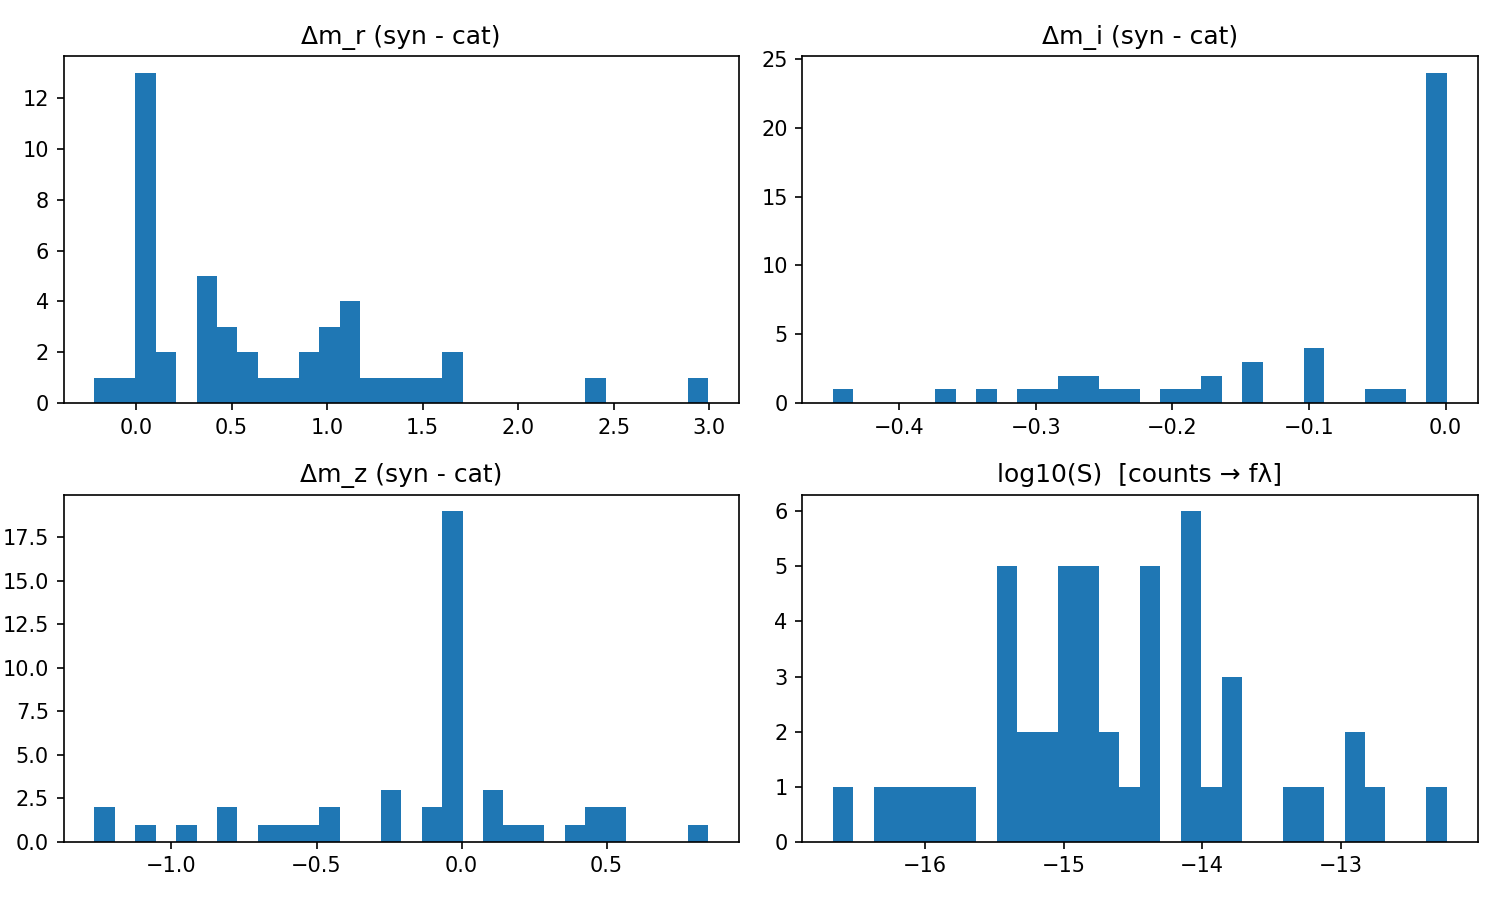

In [9]:
if OUTFILE.exists():
    with fits.open(OUTFILE) as h:
        print("N HDU =", len(h))
        print("First slit =", h[1].name)
        print("Last slit  =", h[-1].name)
        print()
        print("Columns in first slit:")
        print(h[1].data.names)
else:
    print("Missing:", OUTFILE)

if QAPLOT.exists():
    display(Image(filename=QAPLOT))
else:
    print("Missing:", QAPLOT)


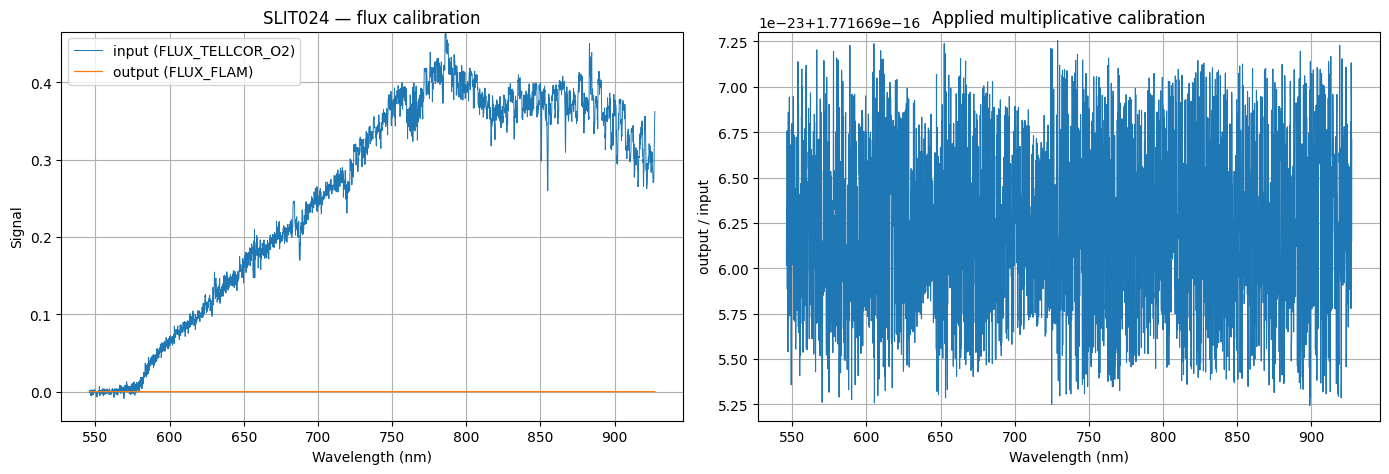

In [10]:
if OUTFILE.exists():
    tin = read_slit_table(INFILE, SLIT)
    tout = read_slit_table(OUTFILE, SLIT)

    lam_in = arr(tin, "LAMBDA_NM")
    flux_in_col = "FLUX_TELLCOR_O2" if "FLUX_TELLCOR_O2" in tin.colnames else ("STELLAR" if "STELLAR" in tin.colnames else "FLUX")
    flux_out_col = "FLUX_FLAM" if "FLUX_FLAM" in tout.colnames else ("FLUX_TELLCOR_O2" if "FLUX_TELLCOR_O2" in tout.colnames else None)

    flux_in = arr(tin, flux_in_col) if flux_in_col else None
    flux_out = arr(tout, flux_out_col) if flux_out_col else None

    hdr = fits.getheader(OUTFILE, SLIT)
    for k in ["CALMODE", "CALSCALE", "CALALPHA", "DM_R", "DM_I", "DM_Z"]:
        if k in hdr:
            print(k, "=", hdr[k])

    if flux_in is not None and flux_out is not None:
        fig = plt.figure(figsize=(14, 5))

        ax = fig.add_subplot(121)
        ax.plot(lam_in, flux_in, lw=0.7, label=f"input ({flux_in_col})")
        ax.plot(lam_in, flux_out, lw=0.9, label=f"output ({flux_out_col})")
        ax.set_title(f"{SLIT} — flux calibration")
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Signal")
        ax.set_ylim(*finite_ylim(flux_in, flux_out))
        ax.legend()

        ax = fig.add_subplot(122)
        ratio = np.full_like(flux_out, np.nan, dtype=float)
        m = np.isfinite(flux_in) & np.isfinite(flux_out) & (np.abs(flux_in) > 0)
        ratio[m] = flux_out[m] / flux_in[m]
        ax.plot(lam_in, ratio, lw=0.8)
        ax.axhline(1.0, lw=0.8, ls="--", color="0.5")
        ax.set_title("Applied multiplicative calibration")
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("output / input")
        ax.set_ylim(*finite_ylim(ratio))

        plt.tight_layout()
        plt.show()
else:
    print("Missing:", OUTFILE)


## Review the QC products inline

The three PDFs below are the final validation products for Step11.

The response-summary PDF is the most important closeout diagnostic:
- it reports the accepted/rejected calibration sample,
- reconstructs the per-slit response curves,
- compares the accepted-star envelope to the master response.


In [11]:
for p in [QC_GRID_PDF, QC_SUMMARY_PDF, QC_RESPONSE_PDF]:
    print(p.name, "->", p.exists())
    if p.exists():
        display(FileLink(str(p.resolve())))


qc_step11_fluxcal_grid.pdf -> True


/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/qc_step11_fluxcal_grid.pdf

qc_step11_summary_pages.pdf -> True


/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/qc_step11_summary_pages.pdf

qc_step11_response_summary.pdf -> True


/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/11_fluxcal/qc_step11/qc_step11_response_summary.pdf

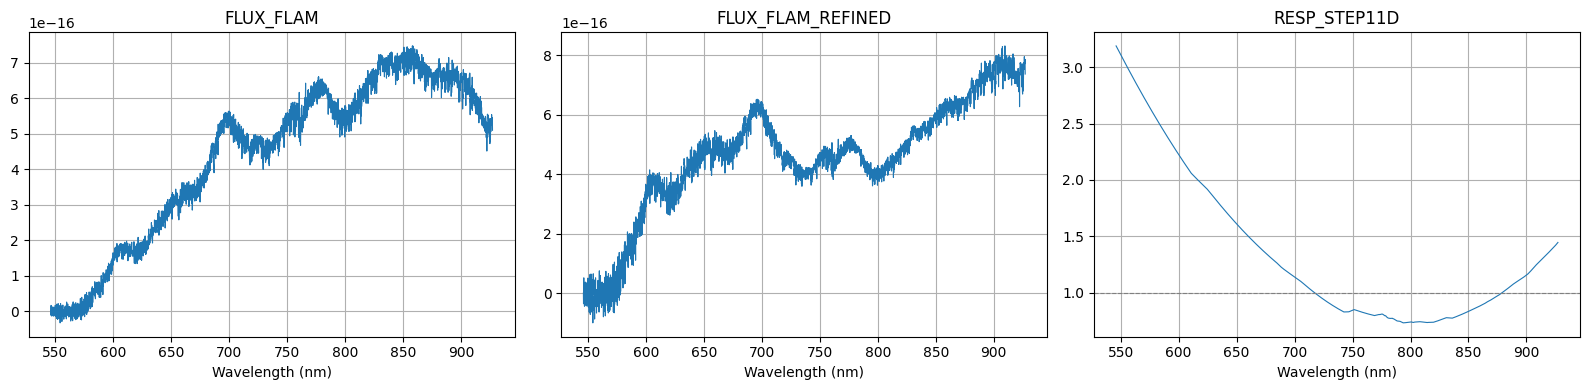

In [35]:
slit = "SLIT027"
refined_file = ROOT11 / "Extract1D_fluxcal_refined_master.fits"

t0 = read_slit_table(OUTFILE, slit)
t1 = read_slit_table(refined_file, slit)

lam = arr(t1, "LAMBDA_NM")
f0 = arr(t0, "FLUX_FLAM")
f1 = arr(t1, "FLUX_FLAM_REFINED")
r1 = arr(t1, "RESP_STEP11D")

m = np.isfinite(lam) & np.isfinite(f0) & np.isfinite(f1) & np.isfinite(r1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(lam[m], f0[m], lw=0.8)
axes[0].set_title("FLUX_FLAM")

axes[1].plot(lam[m], f1[m], lw=0.8)
axes[1].set_title("FLUX_FLAM_REFINED")

axes[2].plot(lam[m], r1[m], lw=0.8)
axes[2].axhline(1.0, lw=0.8, ls="--", color="0.5")
axes[2].set_title("RESP_STEP11D")

for ax in axes:
    ax.set_xlabel("Wavelength (nm)")

plt.tight_layout()
plt.show()

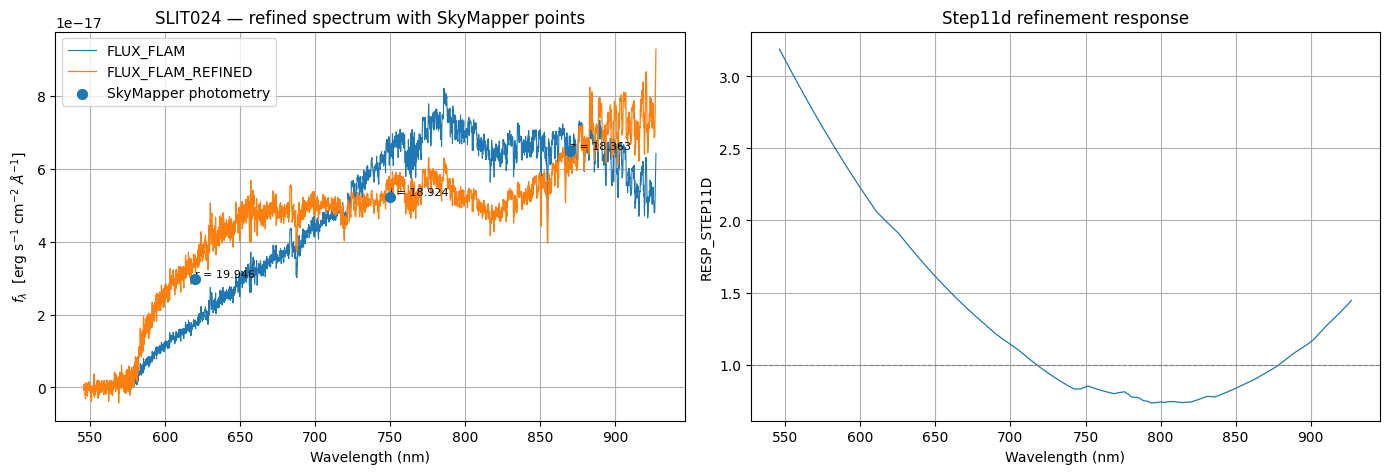

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def abmag_to_flam_cgs(mag_ab, lam_nm):
    """
    Convert AB magnitude to f_lambda in cgs:
      erg s^-1 cm^-2 A^-1
    """
    fnu_cgs = 3631.0 * 10**(-0.4 * mag_ab) * 1e-23   # erg s^-1 cm^-2 Hz^-1
    c_A_s = 2.99792458e18                            # Angstrom / s
    lam_A = lam_nm * 10.0
    return fnu_cgs * c_A_s / (lam_A**2)


# Effective wavelengths used in step11c
LAM_EFF = {
    "r": 620.0,
    "i": 750.0,
    "z": 870.0,
}

# ------------------------------------------------------------
# choose slit
# ------------------------------------------------------------
slit = "SLIT024"

refined_file = ROOT11 / "Extract1D_fluxcal_refined_master.fits"
phot = pd.read_csv(PHOTCSV)
phot["slit"] = phot["slit"].astype(str).str.strip().str.upper()

row = phot.loc[phot["slit"] == slit]
if len(row) != 1:
    raise ValueError(f"Could not find unique photometry row for {slit}")
row = row.iloc[0]

with fits.open(refined_file) as h:
    tab = h[slit].data
    lam = np.asarray(tab["LAMBDA_NM"], float)
    flam0 = np.asarray(tab["FLUX_FLAM"], float)
    flam1 = np.asarray(tab["FLUX_FLAM_REFINED"], float)
    resp = np.asarray(tab["RESP_STEP11D"], float)

# sort by wavelength for plotting
m = np.isfinite(lam) & np.isfinite(flam1)
lam_plot = lam[m]
flam0_plot = flam0[m]
flam1_plot = flam1[m]
resp_plot = resp[m]

order = np.argsort(lam_plot)
lam_plot = lam_plot[order]
flam0_plot = flam0_plot[order]
flam1_plot = flam1_plot[order]
resp_plot = resp_plot[order]

# photometric points
bands = ["r", "i", "z"]
xphot = []
yphot = []
labels = []

for b in bands:
    mag_col = f"{b}_mag"
    if mag_col not in row or not np.isfinite(row[mag_col]):
        continue
    lam_eff = LAM_EFF[b]
    flam_eff = abmag_to_flam_cgs(row[mag_col], lam_eff)
    xphot.append(lam_eff)
    yphot.append(flam_eff)
    labels.append(f"{b} = {row[mag_col]:.3f}")

xphot = np.array(xphot, float)
yphot = np.array(yphot, float)

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# spectrum + photometry
ax = axes[0]
ax.plot(lam_plot, flam0_plot, lw=0.8, label="FLUX_FLAM")
ax.plot(lam_plot, flam1_plot, lw=0.9, label="FLUX_FLAM_REFINED")
ax.scatter(xphot, yphot, s=50, zorder=5, label="SkyMapper photometry")

for x, y, lab in zip(xphot, yphot, labels):
    ax.text(x, y, lab, fontsize=8, ha="left", va="bottom")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel(r"$f_\lambda$  [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]")
ax.set_title(f"{slit} — refined spectrum with SkyMapper points")
ax.legend()

# response
ax = axes[1]
ax.plot(lam_plot, resp_plot, lw=0.9)
ax.axhline(1.0, lw=0.8, ls="--", color="0.5")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("RESP_STEP11D")
ax.set_title("Step11d refinement response")

plt.tight_layout()
plt.show()

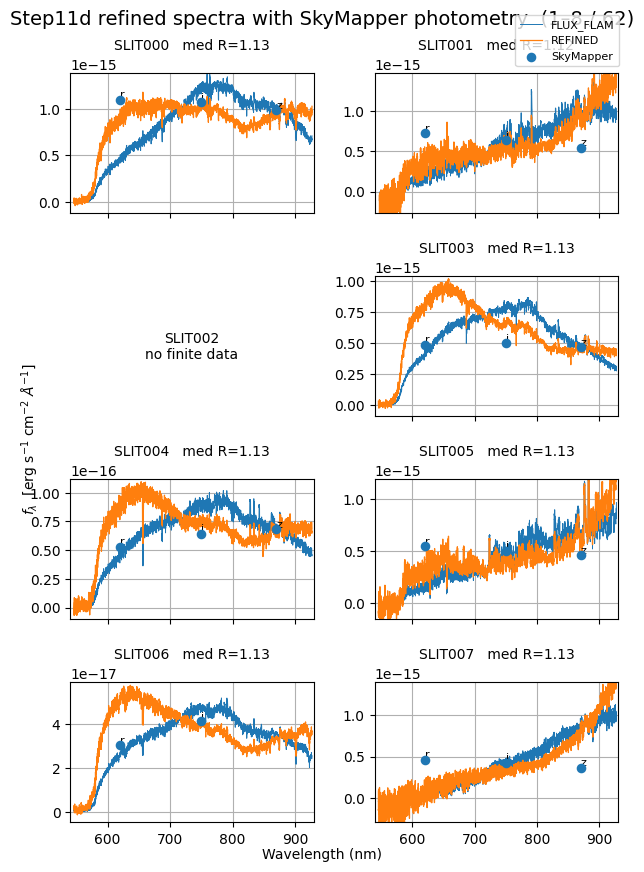

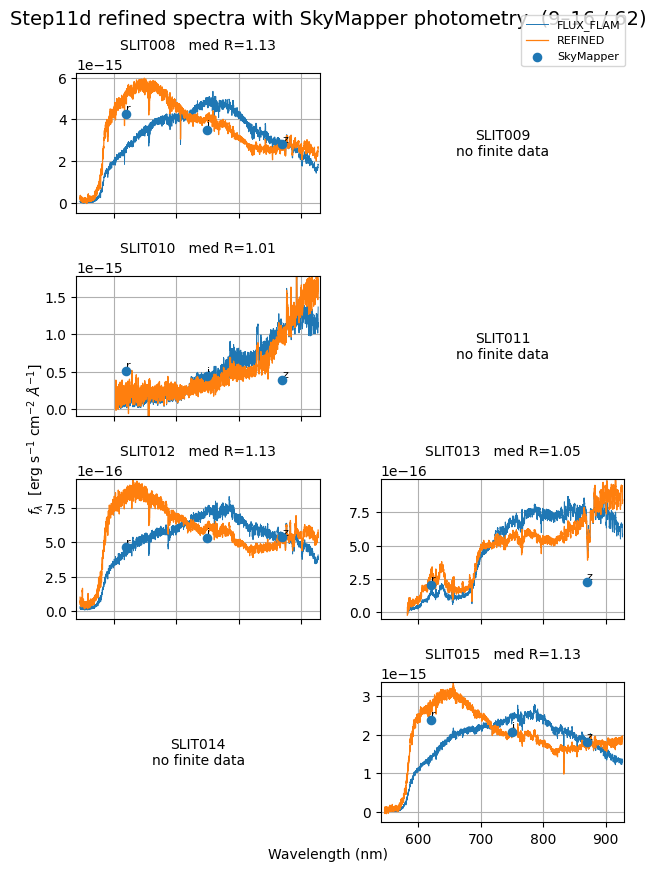

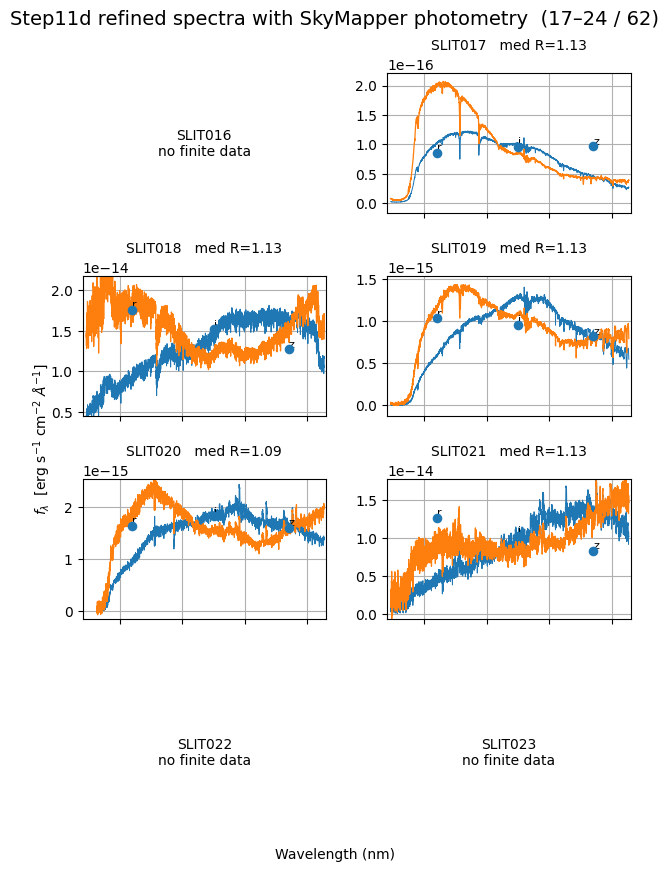

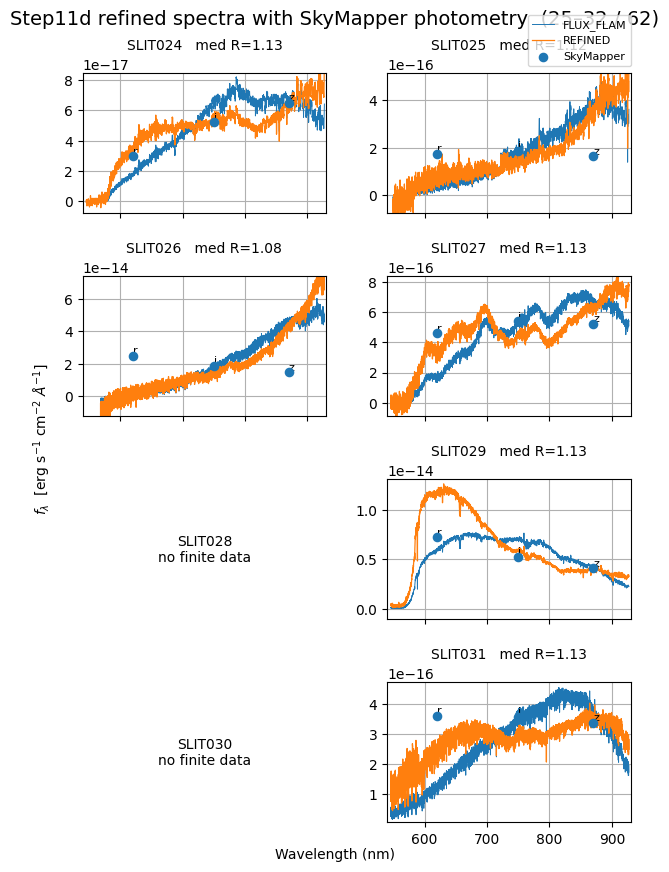

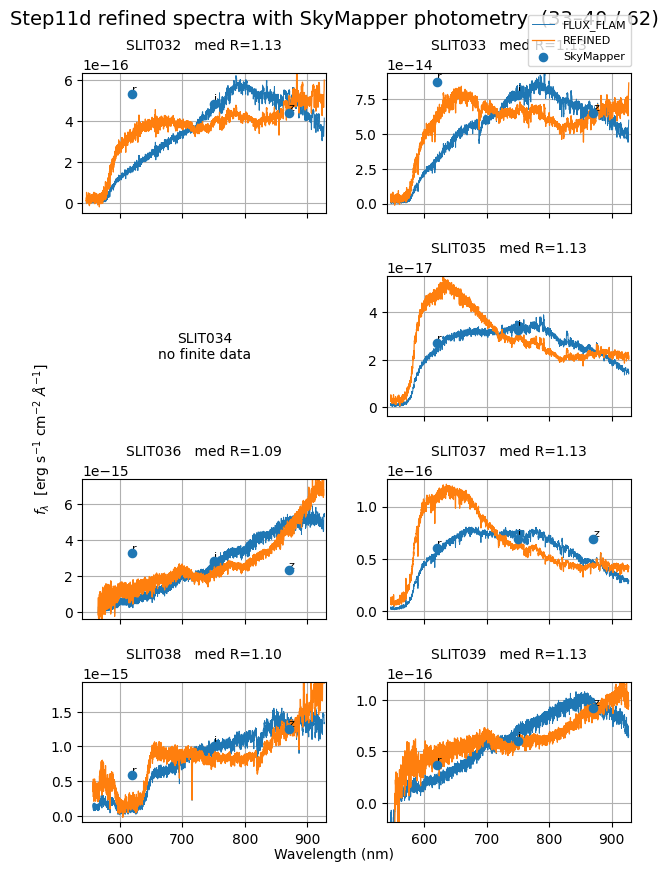

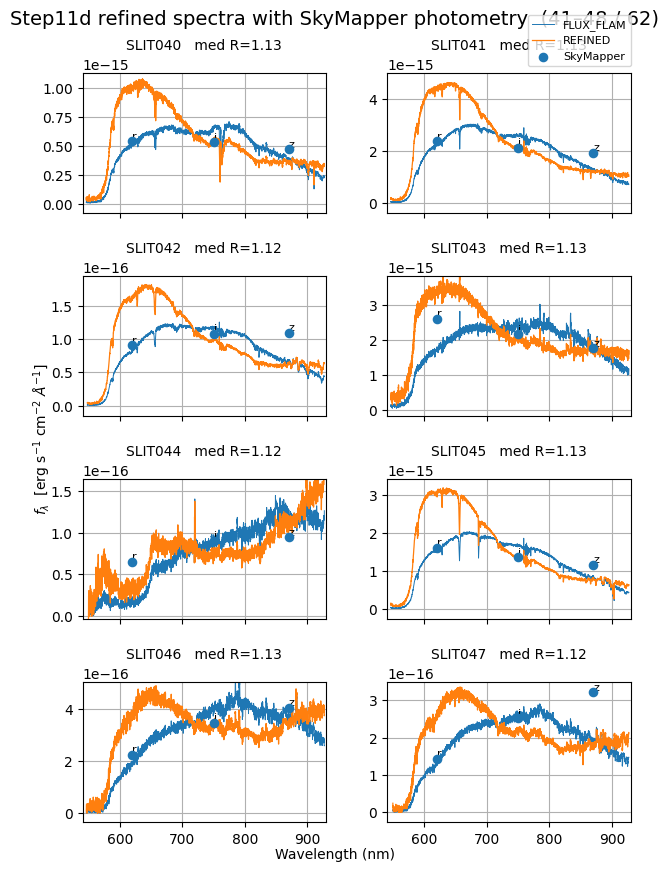

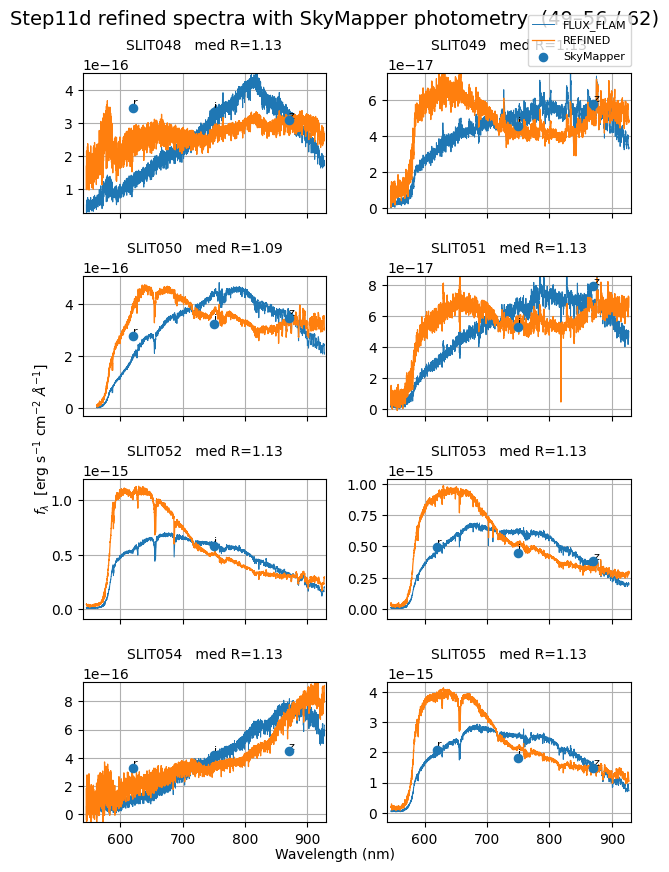

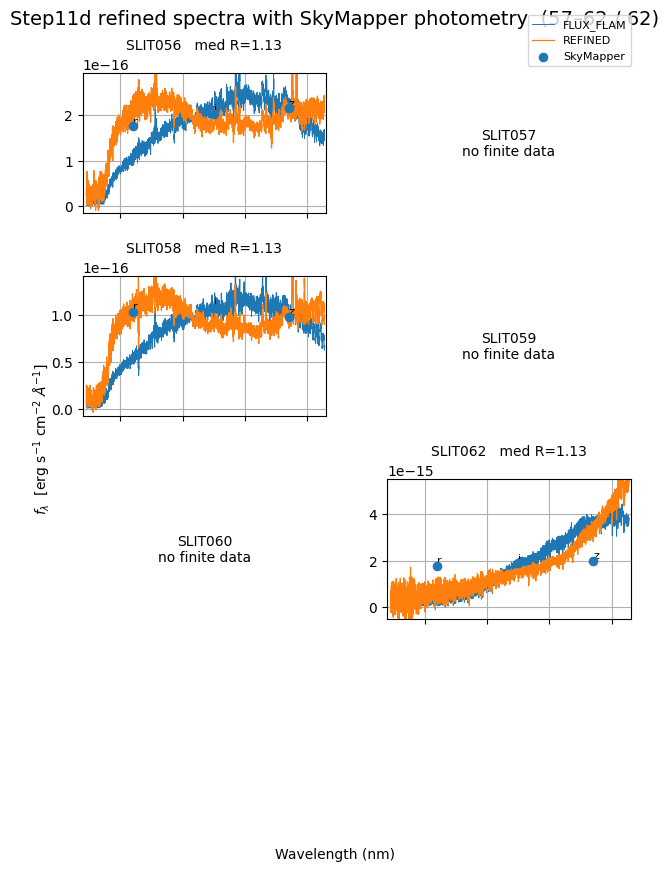

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from IPython.display import display

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def abmag_to_flam_cgs(mag_ab, lam_nm):
    fnu_cgs = 3631.0 * 10**(-0.4 * mag_ab) * 1e-23
    c_A_s = 2.99792458e18
    lam_A = lam_nm * 10.0
    return fnu_cgs * c_A_s / (lam_A**2)

def robust_ylim(y, qlo=2, qhi=98, pad=0.10):
    y = np.asarray(y, float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return (-1, 1)
    lo, hi = np.nanpercentile(y, [qlo, qhi])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        med = np.nanmedian(y)
        return (med - 1, med + 1)
    d = hi - lo
    return lo - pad * d, hi + pad * d

LAM_EFF = {
    "r": 620.0,
    "i": 750.0,
    "z": 870.0,
}

# ------------------------------------------------------------
# inputs
# ------------------------------------------------------------
refined_file = ROOT11 / "Extract1D_fluxcal_refined_master.fits"
phot = pd.read_csv(PHOTCSV)
phot["slit"] = phot["slit"].astype(str).str.strip().str.upper()

slits = phot["slit"].dropna().astype(str).str.strip().str.upper().tolist()

# ------------------------------------------------------------
# layout
# ------------------------------------------------------------
NCOL = 2
NROW = 4
PER_PAGE = NCOL * NROW

# fixed physical size per subplot (cm)
CM = 1 / 2.54
W_SUB = 8.0   # a bit larger
H_SUB = 5.8

FIG_W = NCOL * W_SUB * CM
FIG_H = NROW * H_SUB * CM

# ------------------------------------------------------------
# plotting
# ------------------------------------------------------------
with fits.open(refined_file) as h:
    for i0 in range(0, len(slits), PER_PAGE):
        batch = slits[i0:i0 + PER_PAGE]

        fig, axes = plt.subplots(NROW, NCOL, figsize=(FIG_W, FIG_H), sharex=True)
        axes = np.atleast_1d(axes).ravel()

        for ax, slit in zip(axes, batch):
            if slit not in h:
                ax.text(0.5, 0.5, f"{slit}\nnot found", ha="center", va="center", transform=ax.transAxes)
                ax.set_axis_off()
                continue

            row = phot.loc[phot["slit"] == slit]
            if len(row) != 1:
                ax.text(0.5, 0.5, f"{slit}\nno unique phot row", ha="center", va="center", transform=ax.transAxes)
                ax.set_axis_off()
                continue
            row = row.iloc[0]

            tab = h[slit].data
            lam = np.asarray(tab["LAMBDA_NM"], float)
            flam0 = np.asarray(tab["FLUX_FLAM"], float)
            flam1 = np.asarray(tab["FLUX_FLAM_REFINED"], float)
            resp = np.asarray(tab["RESP_STEP11D"], float)

            m = np.isfinite(lam) & np.isfinite(flam1)
            lam = lam[m]
            flam0 = flam0[m]
            flam1 = flam1[m]
            resp = resp[m]

            if lam.size == 0:
                ax.text(0.5, 0.5, f"{slit}\nno finite data", ha="center", va="center", transform=ax.transAxes)
                ax.set_axis_off()
                continue

            order = np.argsort(lam)
            lam = lam[order]
            flam0 = flam0[order]
            flam1 = flam1[order]
            resp = resp[order]

            ax.plot(lam, flam0, lw=0.7, label="FLUX_FLAM")
            ax.plot(lam, flam1, lw=0.9, label="REFINED")

            xphot, yphot = [], []
            for b in ["r", "i", "z"]:
                mag_col = f"{b}_mag"
                if mag_col in row and np.isfinite(row[mag_col]):
                    lam_eff = LAM_EFF[b]
                    flam_eff = abmag_to_flam_cgs(row[mag_col], lam_eff)
                    xphot.append(lam_eff)
                    yphot.append(flam_eff)
                    ax.text(lam_eff, flam_eff, b, fontsize=8, ha="left", va="bottom")

            if xphot:
                ax.scatter(xphot, yphot, s=35, zorder=5, label="SkyMapper")

            vals = [flam0[np.isfinite(flam0)], flam1[np.isfinite(flam1)]]
            if len(yphot):
                vals.append(np.array(yphot, float))

            ax.set_title(f"{slit}   med R={np.nanmedian(resp):.2f}", fontsize=10)
            ax.set_xlim(540, 930)
            ax.set_ylim(*robust_ylim(np.concatenate(vals)))   # <-- tuned per slit

        for ax in axes[len(batch):]:
            ax.set_axis_off()

        fig.suptitle(
            f"Step11d refined spectra with SkyMapper photometry  ({i0+1}–{i0+len(batch)} / {len(slits)})",
            y=0.97,
            fontsize=14,
        )
        fig.text(0.5, 0.04, "Wavelength (nm)", ha="center")
        fig.text(0.02, 0.5, r"$f_\lambda$  [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]", va="center", rotation="vertical")

        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.97), fontsize=8)

        fig.subplots_adjust(
            left=0.10,
            right=0.97,
            bottom=0.08,
            top=0.90,
            wspace=0.25,
            hspace=0.45,
        )

        display(fig)
        plt.close(fig)

In [42]:
import numpy as np
import pandas as pd
from astropy.io import fits

def load_filter_curve(path):
    arr = np.loadtxt(path, comments="#", usecols=(0, 1))
    lam = np.asarray(arr[:, 0], float)
    thr = np.asarray(arr[:, 1], float)
    order = np.argsort(lam)
    return lam[order], thr[order]

def trapz(y, x):
    return float(np.trapz(y, x))

def abmag_to_fnu_cgs(mag_ab):
    # erg s^-1 cm^-2 Hz^-1
    return 3631.0 * 10**(-0.4 * mag_ab) * 1e-23

def synth_band_quantity_from_flam(wave_nm, flam, filt_nm, filt_thr):
    good = np.isfinite(wave_nm) & np.isfinite(flam)
    wave_nm = np.asarray(wave_nm[good], float)
    flam = np.asarray(flam[good], float)
    if wave_nm.size < 10:
        return np.nan

    thr = np.interp(wave_nm, filt_nm, filt_thr, left=0.0, right=0.0)
    m = np.isfinite(thr) & (thr > 0)
    if np.sum(m) < 10:
        return np.nan

    return trapz(flam[m] * thr[m] * wave_nm[m], wave_nm[m])

def trapz_sorted(y, x):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 2:
        return np.nan
    x = x[m]
    y = y[m]
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    return float(np.trapz(y, x))


def synth_band_quantity_from_flam(wave_nm, flam, filt_nm, filt_thr):
    good = np.isfinite(wave_nm) & np.isfinite(flam)
    wave_nm = np.asarray(wave_nm[good], float)
    flam = np.asarray(flam[good], float)
    if wave_nm.size < 10:
        return np.nan

    # sort spectrum by wavelength
    order = np.argsort(wave_nm)
    wave_nm = wave_nm[order]
    flam = flam[order]

    thr = np.interp(wave_nm, filt_nm, filt_thr, left=0.0, right=0.0)
    m = np.isfinite(thr) & (thr > 0)
    if np.sum(m) < 10:
        return np.nan

    return trapz_sorted(flam[m] * thr[m] * wave_nm[m], wave_nm[m])


def target_band_quantity_from_ab(mag_ab, wave_nm, tran):
    fnu = 3631.0 * 10**(-0.4 * mag_ab) * 1e-23
    c_ang_s = 2.99792458e18
    wave_A = wave_nm * 10.0
    flam = fnu * c_ang_s / (wave_A**2)

    # also sort by wavelength
    order = np.argsort(wave_nm)
    wave_nm = np.asarray(wave_nm, float)[order]
    tran = np.asarray(tran, float)[order]
    flam = np.asarray(flam, float)[order]

    return trapz_sorted(flam * tran * wave_nm, wave_nm)    

# paths
refined_file = ROOT11 / "Extract1D_fluxcal_refined_master.fits"
phot = pd.read_csv(PHOTCSV)
phot["slit"] = phot["slit"].astype(str).str.strip().str.upper()

r_band = REPO / "calibration/reference_tables/filters/skymapper_r_nm.txt"
i_band = REPO / "calibration/reference_tables/filters/skymapper_i_nm.txt"
z_band = REPO / "calibration/reference_tables/filters/skymapper_z_nm.txt"

fr, tr = load_filter_curve(r_band)
fi, ti = load_filter_curve(i_band)
fz, tz = load_filter_curve(z_band)

slit = "SLIT024"
row = phot.loc[phot["slit"] == slit].iloc[0]

with fits.open(refined_file) as h:
    tab = h[slit].data
    lam = np.asarray(tab["LAMBDA_NM"], float)
    flam = np.asarray(tab["FLUX_FLAM_REFINED"], float)

Yr_syn = synth_band_quantity_from_flam(lam, flam, fr, tr)
Yi_syn = synth_band_quantity_from_flam(lam, flam, fi, ti)
Yz_syn = synth_band_quantity_from_flam(lam, flam, fz, tz)

Yr_cat = target_band_quantity_from_ab(row["r_mag"], fr, tr)
Yi_cat = target_band_quantity_from_ab(row["i_mag"], fi, ti)
Yz_cat = target_band_quantity_from_ab(row["z_mag"], fz, tz)

print("Slit:", slit)
print("Synthetic Y  r,i,z:", Yr_syn, Yi_syn, Yz_syn)
print("Catalog   Y  r,i,z:", Yr_cat, Yi_cat, Yz_cat)
print("Ratio syn/cat r,i,z:",
      Yr_syn / Yr_cat if np.isfinite(Yr_syn) and np.isfinite(Yr_cat) and Yr_cat != 0 else np.nan,
      Yi_syn / Yi_cat if np.isfinite(Yi_syn) and np.isfinite(Yi_cat) and Yi_cat != 0 else np.nan,
      Yz_syn / Yz_cat if np.isfinite(Yz_syn) and np.isfinite(Yz_cat) and Yz_cat != 0 else np.nan)

Slit: SLIT024
Synthetic Y  r,i,z: 2.732783748599564e-12 4.905932051558653e-12 4.2363853139935756e-12
Catalog   Y  r,i,z: 2.8485606394166757e-12 4.541924875699913e-12 5.992233766696587e-12
Ratio syn/cat r,i,z: 0.9593560027422059 1.0801438125509828 0.706979313380329


In [41]:
slit = "SLIT024"
refined_file = ROOT11 / "Extract1D_fluxcal_refined_master.fits"

with fits.open(refined_file) as h:
    lam = np.asarray(h[slit].data["LAMBDA_NM"], float)

m = np.isfinite(lam)
print("first 5 lambda:", lam[m][:5])
print("last  5 lambda:", lam[m][-5:])
print("increasing?", np.all(np.diff(lam[m]) > 0))
print("decreasing?", np.all(np.diff(lam[m]) < 0))

first 5 lambda: [927.17767334 927.05279541 926.92797852 926.80310059 926.67822266]
last  5 lambda: [546.47131348 546.35510254 546.23883057 546.12261963 546.00640869]
increasing? False
decreasing? True


In [39]:
slit = "SLIT024"
refined_file = ROOT11 / "Extract1D_fluxcal_refined_master.fits"

with fits.open(refined_file) as h:
    tab = h[slit].data
    lam = np.asarray(tab["LAMBDA_NM"], float)
    f0 = np.asarray(tab["FLUX_FLAM"], float)
    f1 = np.asarray(tab["FLUX_FLAM_REFINED"], float)
    r1 = np.asarray(tab["RESP_STEP11D"], float)

for name, arr in [("FLUX_FLAM", f0), ("FLUX_FLAM_REFINED", f1), ("RESP_STEP11D", r1)]:
    m = np.isfinite(arr)
    print(name)
    print("  min/med/max =", np.nanmin(arr[m]), np.nanmedian(arr[m]), np.nanmax(arr[m]))
    print("  npos/nneg   =", np.sum(arr[m] > 0), np.sum(arr[m] < 0))

FLUX_FLAM
  min/med/max = -1.565116295227403e-18 5.308112454778732e-17 8.211607891015608e-17
  npos/nneg   = 2985 115
FLUX_FLAM_REFINED
  min/med/max = -4.299659478767679e-18 4.995964193556055e-17 9.283688748825895e-17
  npos/nneg   = 2985 115
RESP_STEP11D
  min/med/max = 0.733579673460506 1.1253637829662848 3.1876788275561623
  npos/nneg   = 3100 0


## Interpretation

For the current Run 8 / Dolidze 25 dataset, the response-summary QC demonstrates that:

- a majority of candidate calibration slits are accepted,
- rejected slits are dominated by non-physical or under-constrained solutions,
- the accepted response curves define a coherent ensemble,
- the master response lies within the ensemble envelope.

This is the final validation step for Step11 absolute flux calibration.


## Handoff

Main products:
- `Extract1D_fluxcal.fits`
- `Step11_fluxcal_summary.csv`
- `Step11_fluxcal_QA.png`
- `qc_step11_fluxcal_grid.pdf`
- `qc_step11_summary_pages.pdf`
- `qc_step11_response_summary.pdf`

Once this notebook runs cleanly, the Step11 products and QC are ready for:
- pipeline documentation,
- paper figures and text,
- repository freeze / GitHub upload.
